# Gradient Descent and Newton optimization methods

## Part 1: Oracle implementation and testing (3 pts)

Optimization starts with oracle implementation - some procedure that calculate at given point $x$ the value of optimizing function $f(x)$, its gradient $\nabla f(x)$ and if needed (e.g. for second-order optimization methods) its Hessian matrix $\nabla^2f(x)$.

In [20]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm.notebook import tqdm  # useful for showing progress of optimization methods
from sklearn.datasets import load_svmlight_file  # useful for loading data from svmlight collection of datasets

In [21]:
class BaseOracle:
    """
        Implementation of base oracle class. All particular oracles should be inherited from this class.
    """
    
    def get_dim(self):
        """
            Returns dimensionality of input vector x
        """
        
        raise NotImplementedError('The function is not implemented')
    
    def func(self, x):
        """
            Returns function value for given x
        """
        
        raise NotImplementedError('The function is not implemented')

    def grad(self, x):
        """
            Returns gradient vector for given x
        """
        
        raise NotImplementedError('The function is not implemented')
        
    def hess(self, x):
        """
            Return Hessian matrix for given x
        """
        
        raise NotImplementedError('The function is not implemented')
    
    def funcgrad(self, x):
        """
            Reimplement this function in your oracle
            if computation of function value and its gradient together
            can be done more efficient (e.g. because of some nested computations like matrix-vector products)
        """
        
        f = self.func(x)
        g = self.grad(x)
        return f, g
    
    def funcgradhess(self, x):
        """
            Reimplement this function in your oracle
            if computation of function value, its gradient and Hessian together
            can be done more efficient (e.g. because of some nested computations like matrix-vector products)
        """

        f = self.func(x)
        g = self.grad(x)
        H = self.hess(x)
        return f, g, H
        

### Task 1.1. Quadratic Oracle (1 pts)

First let's implement oracle for quadratic function
$$
    f(\vec{x}) = \frac{1}{2}\vec{x}^TA\vec{x} - \vec{x}^T\vec{b}.
$$
Here $\vec{x},\vec{b}\in\mathbb{R}^n$, $A\in\mathbb{R}^{n{\times}n}$ &ndash; symmetric and positively definite matrix (otherwise the function does not have a minimum).

In [22]:
class QuadraticOracle(BaseOracle):
    def __init__(self, A, b):
        A = np.array(A, dtype=np.float64)
        b = np.array(b, dtype=np.float64)
        assert A.shape[0] == A.shape[1], "A must be square"
        assert A.shape[0] == b.shape[0], "Dimensions of A and b must match"
        assert np.allclose(A, A.T), "A must be symmetric"
        eigvals = np.linalg.eigvalsh(A)
        assert np.all(eigvals > 0), "A must be positive definite"
        self.A = A
        self.b = b
        self.n = A.shape[0]

    def get_dim(self):
        return self.n
        
    def func(self, x):
        return 0.5 * x @ self.A @ x - self.b @ x
    
    def grad(self, x):
        return self.A @ x - self.b

    def hess(self, x):
        return self.A.copy()
    
    def funcgrad(self, x):
        Ax = self.A @ x
        f = 0.5 * x @ Ax - self.b @ x
        g = Ax - self.b
        return f, g
        
    def funcgradhess(self, x):
        Ax = self.A @ x
        f = 0.5 * x @ Ax - self.b @ x
        g = Ax - self.b
        return f, g, self.A.copy()


After oracle implementation it is a good practice to check its correctness by some finite difference scheme. For example, for symmetric finite difference
$$
    \nabla f(\vec{x})^T\vec{d}\approx \frac{f(\vec{x}+\varepsilon\vec{d}) - f(\vec{x}-\varepsilon\vec{d})}{2\varepsilon}.
$$
Here the optimal $\varepsilon=\varepsilon_{mach}^{1/3}$ and the deviation between $\nabla f(\vec{x})^T\vec{d}$ and its finite difference approximation should be of order $\varepsilon_{mach}^{2/3}$.

Please note that a successful check by this scheme does not give full confidence in the correct oracle implementation. For example, if we multiply the function and its gradient by the same constant, the finite difference check would succeed but the oracle implementation would be incorrect. So some additional checks might be useful here.


In [23]:
def check_grad(func, grad, x):
    """
        The function generates random direction d of the same size as input x
        and check correspondence between function value and its gradient 
        by using some finite difference scheme
        
        Returns:
        the absolute difference between grad f(x)^Td and its finite difference approximation
    """
    eps = np.finfo(np.float64).eps ** (1.0 / 3.0)
    d = np.random.randn(x.shape[0])
    d = d / np.linalg.norm(d)
    grad_exact = grad(x) @ d
    grad_approx = (func(x + eps * d) - func(x - eps * d)) / (2.0 * eps)
    return abs(grad_exact - grad_approx)

In [24]:
# Some checks
N = 10
x = np.random.randn(N)
A = np.random.randn(N, N)
A = A.dot(A.T)
b = np.random.randn(N)
oracle = QuadraticOracle(A, b)

# Check correspondence between function and its gradient
res = check_grad(oracle.func, oracle.grad, x)
assert res < 1e-8, f"Tolerance {res:.1e} seems to be too big" 

# Check correspondence between gradient and Hessian
d = np.random.randn(N)
res = check_grad(lambda x: oracle.grad(x).dot(d), lambda x: oracle.hess(x).dot(d), x)
assert res < 1e-8, f"Tolerance {res:.1e} seems to be too big"


### Task 1.2. Logistic Oracle (1 pts)

Now let's implement the oracle for two-class Logistic Regression with $L_2$-regularization:
$$
    f(\vec{w}) = \frac{1}{N}\sum_{i=1}^N\log(1+\exp(-y_i\vec{w}^T\vec{x}_i)) + \frac{\lambda}{2}\|\vec{w}\|_2^2.
$$
Here $(X,\vec{y}) = \{\vec{x}_i,y_i\}_{i=1}^N$ &ndash; training dataset, $\vec{x}_i\in\mathbb{R}^D$, $y_i\in\{-1,+1\}$ &ndash; class labels, $\lambda > 0$ &ndash; regularization coefficient.

First of all, we need to derive the formulas for $\nabla f(\vec{w})$ and $\nabla^2 f(\vec{w})$. For this reason, let's compute differentials:

$df(\vec{w})[d\vec{w}] = -\frac{1}{N}\sum_{i=1}^N \frac{y_i \vec{x}_i^T d\vec{w} \cdot e^{-y_i \vec{w}^T \vec{x}_i}}{1+e^{-y_i \vec{w}^T \vec{x}_i}} + \lambda \vec{w}^T d\vec{w} = -\frac{1}{N}\sum_{i=1}^N y_i \sigma(-y_i \vec{w}^T \vec{x}_i) \vec{x}_i^T d\vec{w} + \lambda \vec{w}^T d\vec{w}$

where $\sigma(t) = \frac{1}{1+e^{-t}}$ is the sigmoid function.

$d^2f(\vec{w})[d\vec{w}_1,d\vec{w}_2] = \frac{1}{N}\sum_{i=1}^N \sigma(y_i \vec{w}^T \vec{x}_i)(1-\sigma(y_i \vec{w}^T \vec{x}_i))(\vec{x}_i^T d\vec{w}_1)(\vec{x}_i^T d\vec{w}_2) + \lambda d\vec{w}_1^T d\vec{w}_2$


Using these differentials we can find $\nabla f(\vec{w})$ and $\nabla^2 f(\vec{w})$:

$\nabla f(\vec{w}) = -\frac{1}{N}\sum_{i=1}^N y_i \sigma(-y_i \vec{w}^T \vec{x}_i) \vec{x}_i + \lambda \vec{w}$

$\nabla^2 f(\vec{w}) = \frac{1}{N}\sum_{i=1}^N \sigma(y_i \vec{w}^T \vec{x}_i)(1-\sigma(y_i \vec{w}^T \vec{x}_i)) \vec{x}_i \vec{x}_i^T + \lambda I$

Then for the reason of efficient implementation we need to express these formulas in matrix/vector form (without any summation over training objects):

Let $\vec{z} = \vec{y} \odot (X\vec{w})$, where $\odot$ denotes element-wise product.

$\nabla f(\vec{w}) = -\frac{1}{N}X^T(\vec{y} \odot \sigma(-\vec{z})) + \lambda \vec{w}$

$\nabla^2f(\vec{w}) = \frac{1}{N}X^T \mathrm{diag}(\sigma(\vec{z}) \odot (1 - \sigma(\vec{z}))) X + \lambda I$

Now we are ready to implement the oracle. For stable numerical computations the functions **np.logaddexp** and **sp.special.expit** may be useful. In this assignment we are going to work with datasets from [SVMLIGHT collection](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/). These datasets are loaded in *scipy.sparse.csr_array* format. So your oracle implementation should support this format as well.

In [25]:
class LogRegL2Oracle(BaseOracle):
    
    def __init__(self, X, y, lambda_):
        self.X = X
        self.y = np.array(y, dtype=np.float64)
        self.lambda_ = lambda_
        self.N, self.D = X.shape
    
    def get_dim(self):
        return self.D
        
    def _Xw(self, w):
        return np.asarray(self.X @ w).ravel()
    
    def _XTv(self, v):
        return np.asarray(self.X.T @ v).ravel()
    
    def func(self, w):
        z = self.y * self._Xw(w)
        loss = np.mean(np.logaddexp(0, -z))
        reg = 0.5 * self.lambda_ * (w @ w)
        return loss + reg
    
    def grad(self, w):
        z = self.y * self._Xw(w)
        s = sp.special.expit(-z)
        return -self._XTv(self.y * s) / self.N + self.lambda_ * w
    
    def hess(self, w):
        z = self.y * self._Xw(w)
        sigma_z = sp.special.expit(z)
        d = sigma_z * (1.0 - sigma_z)
        if sp.sparse.issparse(self.X):
            DX = self.X.multiply(d.reshape(-1, 1))
            H = (self.X.T @ DX).toarray() / self.N + self.lambda_ * np.eye(self.D)
        else:
            DX = self.X * d.reshape(-1, 1)
            H = (self.X.T @ DX) / self.N + self.lambda_ * np.eye(self.D)
        return H
    
    def funcgrad(self, w):
        Xw = self._Xw(w)
        z = self.y * Xw
        f = np.mean(np.logaddexp(0, -z)) + 0.5 * self.lambda_ * (w @ w)
        s = sp.special.expit(-z)
        g = -self._XTv(self.y * s) / self.N + self.lambda_ * w
        return f, g
    
    def funcgradhess(self, w):
        Xw = self._Xw(w)
        z = self.y * Xw
        f = np.mean(np.logaddexp(0, -z)) + 0.5 * self.lambda_ * (w @ w)
        sigma_z = sp.special.expit(z)
        s = 1.0 - sigma_z
        g = -self._XTv(self.y * s) / self.N + self.lambda_ * w
        d = sigma_z * s
        if sp.sparse.issparse(self.X):
            DX = self.X.multiply(d.reshape(-1, 1))
            H = (self.X.T @ DX).toarray() / self.N + self.lambda_ * np.eye(self.D)
        else:
            DX = self.X * d.reshape(-1, 1)
            H = (self.X.T @ DX) / self.N + self.lambda_ * np.eye(self.D)
        return f, g, H

In [26]:
# Some checks
N = 10
D = 8

# Generate random dataset
X = np.random.randn(N, D)
y = 2*np.random.randint(2, size=N)-1
oracle = LogRegL2Oracle(X, y, 1/N)

# Check correspondence between function and its gradient
w = np.random.randn(D)
res = check_grad(oracle.func, oracle.grad, w)
assert res < 1e-8, f"Tolerance {res:.1e} seems to be too big"

# Check correspondence between gradient and Hessian
d = np.random.randn(D)
res = check_grad(lambda w: oracle.grad(w).dot(d), lambda w: oracle.hess(w).dot(d), w)
assert res < 1e-8, f"Tolerance {res:.1e} seems to be too big"

# Generate random dataset in scipy.sparse.csr_array format
num_elem = int(N*D / 3)
data = np.random.randn(num_elem)
row_ind = np.random.randint(N, size=num_elem)
col_ind = np.random.randint(D, size=num_elem)
X = sp.sparse.csr_array((data, (row_ind, col_ind)), shape=(N,D))
y = 2*np.random.randint(2, size=N)-1
oracle = LogRegL2Oracle(X, y, 1/N)

# Check correspondence between function and its gradient
w = np.random.randn(D)
res = check_grad(oracle.func, oracle.grad, w)
assert res < 1e-8, f"Tolerance {res:.1e} seems to be too big"

# Check correspondence between gradient and Hessian
d = np.random.randn(D)
res = check_grad(lambda w: oracle.grad(w).dot(d), lambda w: oracle.hess(w).dot(d), w)
assert res < 1e-8, f"Tolerance {res:.1e} seems to be too big"

# Check values for particular dataset
X = np.arange(80, dtype=np.float64).reshape(10,8)
y = np.concatenate((np.ones(5), -np.ones(5)))
oracle = LogRegL2Oracle(X, y, 1./80)
w = np.arange(8, dtype=np.float64)
f = oracle.func(w)
assert abs(f-854.875) < 1e-5

### Task 1.3. Rosenbrock Oracle (1 pts)

Now let's implement the oracle for multidimensional non-convex [Rosenbrock function](https://en.wikipedia.org/wiki/Rosenbrock_function):
$$
    f(x_1,\dots,x_N) = \sum_{i=1}^{N-1}[100(x_{i+1}-x_i^2)^2 + (1-x_i)^2]
$$
Here $N\ge 2$ &ndash; dimensionality of Rosenbrock function

In [27]:
class RosenbrockOracle(BaseOracle):
    
    def __init__(self, dim=2):
        assert dim >= 2, "Dimension must be at least 2"
        self._dim = dim
    
    def get_dim(self):
        return self._dim
        
    def func(self, x):
        return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1.0 - x[:-1])**2)
    
    def grad(self, x):
        g = np.zeros_like(x, dtype=np.float64)
        diff = x[1:] - x[:-1]**2
        g[:-1] += -400.0 * x[:-1] * diff + 2.0 * (x[:-1] - 1.0)
        g[1:] += 200.0 * diff
        return g
    
    def hess(self, x):
        N = self._dim
        H = np.zeros((N, N))
        idx = np.arange(N - 1)
        H[idx, idx] += 1200.0 * x[:-1]**2 - 400.0 * x[1:] + 2.0
        H[idx + 1, idx + 1] += 200.0
        H[idx, idx + 1] = -400.0 * x[:-1]
        H[idx + 1, idx] = -400.0 * x[:-1]
        return H

In [28]:
# Some checks
dim = 10
oracle = RosenbrockOracle(dim)

# Check correspondence between function and its gradient
x = np.random.randn(dim)
res = check_grad(oracle.func, oracle.grad, x)
assert res < 1e-6, f"Tolerance {res:.1e} seems to be too big"

# Check correspondence between gradient and Hessian
d = np.random.randn(dim)
res = check_grad(lambda x: oracle.grad(x).dot(d), lambda x: oracle.hess(x).dot(d), x)
assert res < 1e-6, f"Tolerance {res:.1e} seems to be too big"

# Check particular values
x = np.arange(5, dtype=np.float64)
oracle = RosenbrockOracle(dim=5)
f = oracle.func(x)
assert abs(f-2806.0) < 1e-5


## Part 2: Gradient Descent - implementation and experiments (4 pts)

Let's consider optimization problem
$$
    f(\vec{x})\rightarrow\min_{\vec{x}}.
$$
The scheme of Gradient Descent method is the following:

- Input: initialization $\vec{x}_0$, tolerance $\varepsilon$.
- For $k=0,1,2,\dots,$
    - Compute gradient $\vec{g}_k = \nabla f(\vec{x}_k)$;
    - Check stopping criterion: if $\|\vec{g}_k\|_2^2\le\varepsilon$, then stop;
    - Compute optimization direction $\vec{d}_k=-\vec{g}_k$;
    - Find stepsize $\alpha_k$ by non-exact one-dimensional optimization $\min_{\alpha_k}f(\vec{x}_k+\alpha_k\vec{d}_k)$ satisfying Armijo-Wolfe conditions;
    - Make step $\vec{x}_{k+1} = \vec{x}_k + \alpha_k\vec{d}_k$.
    
Finding points satisfying Armijo-Wolfe conditions can be done using the function **scipy.optimize.line_search**. However, sometimes this function may return *None* value. In this case a simple backtracking procedure can be used:
- Initialize $\alpha$;
- While True:
    - $\vec{x}_{k+1} = \vec{x}_k + \alpha\vec{d}_k$;
    - if $f(\vec{x}_{k+1}) < f(\vec{x}_k) + c_1\alpha\nabla f(\vec{x}_k)^T\vec{d}_k$ then exit;
    - $\alpha := \alpha\cdot\rho$, where $\rho$ is some value less then 1, e.g. $\rho=0.8$.

Gradient descent is a descent optimization method. So on every iteration the following should be true: $\nabla f(\vec{x}_k)^T\vec{d}_k<0$ and $f(\vec{x}_{k+1})<f(\vec{x}_k)$.

### Task 2.1. GD implementation (1 pts)

Now let's implement GD.

In [29]:
def gd(oracle, x0, tol=1e-4, max_iter=100, disp='None'):
    """
        Gradient descent algorithm
        
        Inputs:
        oracle - an instance of class inherited from BaseOracle
        x0 - initial optimization point, np.ndarray
        tol - optimization tolerance
        max_iter - maximal number of iterations
        disp - verbosity level, can be 'None', 'Progress', 'Iter'. 
            If disp == 'None', then nothing is printed during optimization
            If disp == 'Progress', then general iteration progress is shown using tqdm library
            If disp == 'Iter', then detailed information about every iteration is printed: iteration count,
                function value, norm of gradient, etc.
                
        Outputs:
        x - found solution, np.ndarray
        hist - optimization history, e.g. dictionary with fields 'x', 'func', 'norm_grad', where the information
            about every iteration is stored. You choose yourself the structure of this output.
    """
    x = x0.copy().astype(np.float64)
    hist = {'x': [x.copy()], 'func': [], 'norm_grad': []}
    
    iterator = range(max_iter)
    if disp == 'Progress':
        iterator = tqdm(iterator)
    
    for k in iterator:
        f, g = oracle.funcgrad(x)
        norm_g = np.linalg.norm(g)
        hist['func'].append(f)
        hist['norm_grad'].append(norm_g)
        
        if disp == 'Iter':
            print(f"Iter {k}: f = {f:.6e}, ||g|| = {norm_g:.6e}")
        
        if norm_g ** 2 <= tol:
            break
        
        d = -g
        
        ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f)
        alpha = ls[0]
        
        if alpha is None:
            alpha = 1.0
            c1 = 1e-4
            rho = 0.8
            gTd = g @ d
            while alpha > 1e-16:
                if oracle.func(x + alpha * d) < f + c1 * alpha * gTd:
                    break
                alpha *= rho
        
        x = x + alpha * d
        hist['x'].append(x.copy())
    
    return x, hist


From theoretical point of view it is known that for GD the following is true:
$$
    f(\vec{x}_k)-f_{opt} \le \left(1-\frac{\mu}{L}\right)^k(f(\vec{x}_0)-f_{opt}).
$$
Here $L$ is Lischitz constant for function gradient and $\mu$ is constant of strong convexity. For quadratic oracle $L=\lambda_{max}(A)$, $\mu=\lambda_{min}(A)$. So GD has at least linear convergence rate and its convergence speed is heavily defined by the function condition number $L/\mu$. Let's look at actual behavour of GD optimization method in a series of experiments.

### Task 2.2. GD trajectory for two-dimensional functions (1 pts)

First of all, let's see the GD trajectory for two-dimensional functions. Generate two two-dimensional quadratic functions - one with small condition number and one with big condition number. Plot level set for these functions together with GD trajectory. Can we observe severe increase of number of iterations for the case of poorly-scaled function? Recommendation: choose initial optimization point closer to eigenvector with smaller eigenvalue.

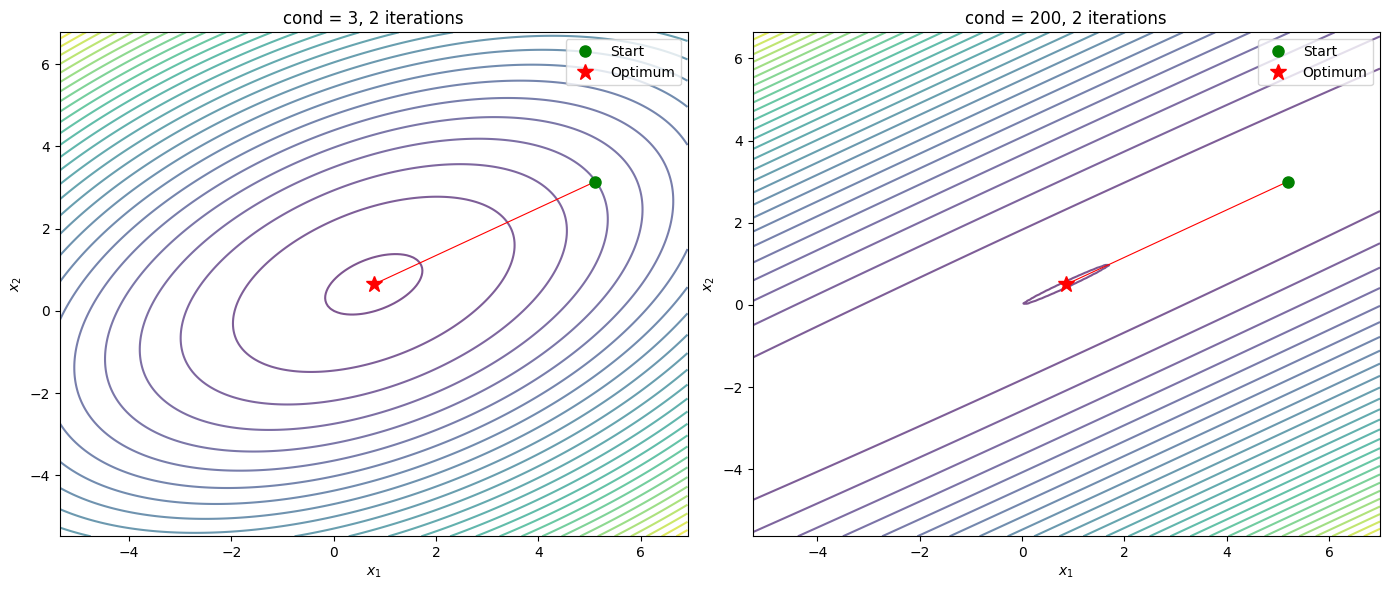

In [30]:
def generate_quadratic(n, cond, rng=None):
    """Generate a random quadratic oracle with given condition number."""
    if rng is None:
        rng = np.random.RandomState()
    Q, _ = np.linalg.qr(rng.randn(n, n))
    eigvals = np.geomspace(1, cond, n)
    A = Q @ np.diag(eigvals) @ Q.T
    A = (A + A.T) / 2
    b = rng.randn(n)
    return QuadraticOracle(A, b)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (cond, ax) in enumerate(zip([3, 200], axes)):
    np.random.seed(42)
    theta = np.pi / 6
    Q = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    eigvals = np.array([1.0, float(cond)])
    A = Q @ np.diag(eigvals) @ Q.T
    b = Q @ np.array([1.0, 0.5])
    oracle = QuadraticOracle(A, b)
    x_opt = np.linalg.solve(A, b)
    
    # Start near eigenvector with smaller eigenvalue
    v_min = Q[:, 0]
    x0 = x_opt + 5.0 * v_min
    
    x, hist = gd(oracle, x0, tol=1e-10, max_iter=5000)
    xs = np.array(hist['x'])
    
    all_pts = np.vstack([xs, x_opt.reshape(1, -1)])
    margin = np.max(np.abs(all_pts - x_opt)) * 1.3 + 0.5
    x1g = np.linspace(x_opt[0] - margin, x_opt[0] + margin, 200)
    x2g = np.linspace(x_opt[1] - margin, x_opt[1] + margin, 200)
    X1, X2 = np.meshgrid(x1g, x2g)
    Z = 0.5 * (A[0,0]*X1**2 + 2*A[0,1]*X1*X2 + A[1,1]*X2**2) - b[0]*X1 - b[1]*X2
    
    ax.contour(X1, X2, Z, levels=30, alpha=0.7)
    ax.plot(xs[:, 0], xs[:, 1], 'r.-', markersize=3, linewidth=0.8)
    ax.plot(xs[0, 0], xs[0, 1], 'go', markersize=8, label='Start')
    ax.plot(x_opt[0], x_opt[1], 'r*', markersize=12, label='Optimum')
    ax.set_title(f'cond = {cond}, {len(hist["func"])} iterations')
    ax.legend()
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.show()


### Task 2.3. GD behaviour w.r.t. optimization tolerance (2/3 pts)

Now let's investigate the GD behaviour w.r.t. optimization tolerance $\varepsilon$. Fix optimization problem dimension, condition number and look at number of iterations needed for convergence for different values of $\varepsilon$. For better reproducibility estimate the number of iterations by averaging w.r.t. several quadratic functions. Choose $\varepsilon$ in log-scale. Does the method in practice show linear convergence rate behaviour predicted from the theoretical results or sometimes can it show faster superlinear behaviour?

/tmp/ipython-input-2786325183.py:42: LineSearchWarning: The line search algorithm did not converge
  ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f)


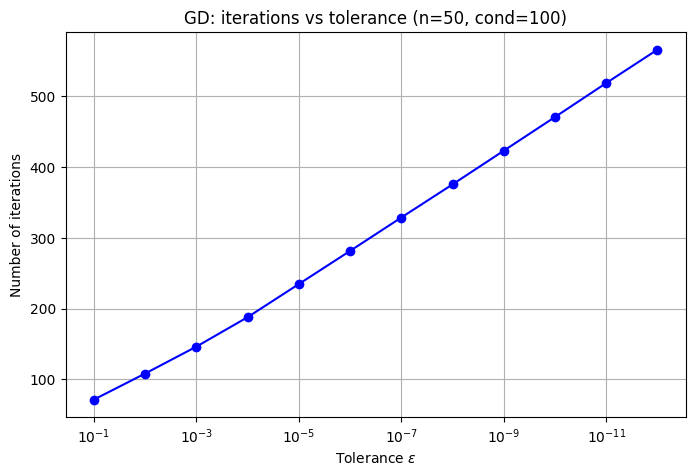

In [31]:
np.random.seed(42)
n = 50
cond = 100
num_trials = 5
tols = np.logspace(-1, -12, 12)

avg_iters = []
for tol in tols:
    iters = []
    for trial in range(num_trials):
        oracle = generate_quadratic(n, cond, rng=np.random.RandomState(trial))
        x0 = np.random.RandomState(trial + 100).randn(n)
        _, hist = gd(oracle, x0, tol=tol, max_iter=50000)
        iters.append(len(hist['func']))
    avg_iters.append(np.mean(iters))

plt.figure(figsize=(8, 5))
plt.semilogx(tols, avg_iters, 'bo-')
plt.xlabel('Tolerance $\\varepsilon$')
plt.ylabel('Number of iterations')
plt.title(f'GD: iterations vs tolerance (n={n}, cond={cond})')
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()


The number of iterations grows approximately linearly with $\log(1/\varepsilon)$, confirming the theoretical linear convergence rate of GD.

### Task 2.4. GD behaviour w.r.t. condition number (2/3 pts)

Now let's investigate the GD behaviour w.r.t. problem condition number $L/\mu$. Fix optimization problem dimension, optimization tolerance and look at the number of iterations needed for convergence for different condition numbers. For better reproducibility estimate the number of iterations by averaging w.r.t. several quadratic functions. From theoretical analysis we know the following:
$$
    \left(1-\frac{\mu}{L}\right)^k(f(\vec{x}_0)-f_{opt})=\varepsilon\ \Rightarrow\ k = \frac{\log(\varepsilon)}{\log(1-\mu/L)}+\mathrm{const} = \{L/\mu\gg 1\Rightarrow\log(1-\mu/L)\approx(-\mu/L)\} \approx\frac{L}{\mu}\log(1/\varepsilon) + \mathrm{const}.
$$
So from this reasoning we are expecting a linear dependence of number of iterations w.r.t. condition number. Can we see such behaviour in practice?

/tmp/ipython-input-2786325183.py:42: LineSearchWarning: The line search algorithm did not converge
  ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f)


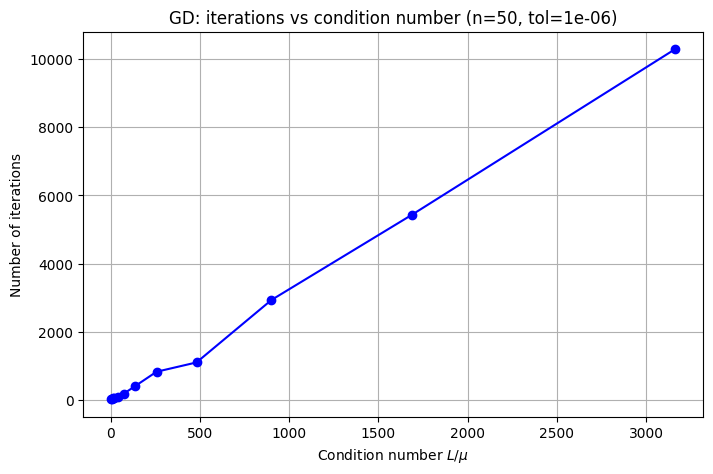

In [32]:
np.random.seed(42)
n = 50
tol = 1e-6
num_trials = 5
conds = np.logspace(0.5, 3.5, 12)

avg_iters = []
for cond in conds:
    iters = []
    for trial in range(num_trials):
        oracle = generate_quadratic(n, cond, rng=np.random.RandomState(trial))
        x0 = np.random.RandomState(trial + 100).randn(n)
        _, hist = gd(oracle, x0, tol=tol, max_iter=100000)
        iters.append(len(hist['func']))
    avg_iters.append(np.mean(iters))

plt.figure(figsize=(8, 5))
plt.plot(conds, avg_iters, 'bo-')
plt.xlabel('Condition number $L/\\mu$')
plt.ylabel('Number of iterations')
plt.title(f'GD: iterations vs condition number (n={n}, tol={tol})')
plt.grid(True)
plt.show()


The number of iterations grows approximately linearly with the condition number, matching the theoretical prediction: $k \sim (L/\mu) \cdot \log(1/\varepsilon)$.

### Task 2.5. GD behaviour w.r.t. problem dimension (2/3 pts)

Finally let's see the GD behaviour w.r.t optimization problem dimension. Fix optimization tolerance, condition number and look at the number of iterations needed for convergence for different problem dimension. For better reproducibility estimate the number of iterations by averaging w.r.t. several quadratic functions. What can we say about this dependence?

/tmp/ipython-input-2786325183.py:42: LineSearchWarning: The line search algorithm did not converge
  ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f)


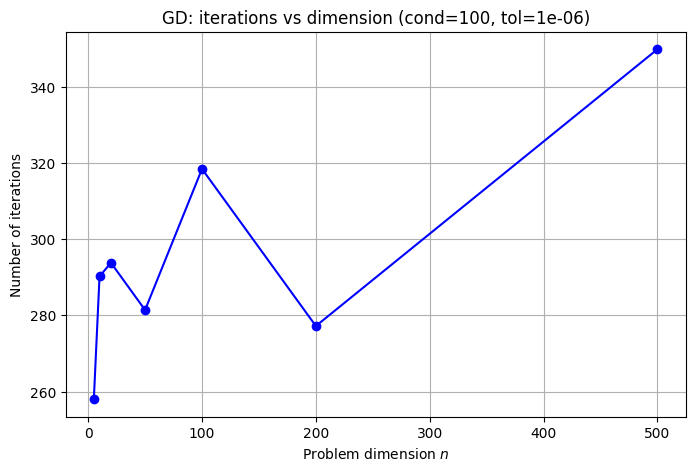

In [33]:
np.random.seed(42)
cond = 100
tol = 1e-6
num_trials = 5
dims = [5, 10, 20, 50, 100, 200, 500]

avg_iters = []
for n in dims:
    iters = []
    for trial in range(num_trials):
        oracle = generate_quadratic(n, cond, rng=np.random.RandomState(trial))
        x0 = np.random.RandomState(trial + 100).randn(n)
        _, hist = gd(oracle, x0, tol=tol, max_iter=50000)
        iters.append(len(hist['func']))
    avg_iters.append(np.mean(iters))

plt.figure(figsize=(8, 5))
plt.plot(dims, avg_iters, 'bo-')
plt.xlabel('Problem dimension $n$')
plt.ylabel('Number of iterations')
plt.title(f'GD: iterations vs dimension (cond={cond}, tol={tol})')
plt.grid(True)
plt.show()


## Part 3. Newton method implementation (3 pts)

Let's consider optimization problem
$$
    f(\vec{x})\rightarrow\min_{\vec{x}}.
$$
The scheme of Newton method is the following:

- Input: initialization $\vec{x}_0$, tolerance $\varepsilon$.
- For $k=0,1,2,\dots,$
    - Compute gradient $\vec{g}_k = \nabla f(\vec{x}_k)$ and Hessian $H_k=\nabla^2f(\vec{x}_k)$;
    - Check stopping criterion: if $\|\vec{g}_k\|_2^2\le\varepsilon$, then stop;
    - In case of non-convex function $f(\vec{x})$ make curvature correction for Hessian $H_k$;
    - Find optimization direction $\vec{d}_k$ by solving linear system $H_k\vec{d}_k = -\vec{g}_k$;
    - Find stepsize $\alpha_k$ by non-exact one-dimensional optimization $\min_{\alpha_k}f(\vec{x}_k+\alpha_k\vec{d}_k)$ satisfying Armijo-Wolfe conditions, starting from $\alpha_{start}=1$;
    - Make step $\vec{x}_{k+1} = \vec{x}_k + \alpha_k\vec{d}_k$.
    
Newton method is a descent optimization method. So on every iteration the following should be true: $\nabla f(\vec{x}_k)^T\vec{d}_k<0$ and $f(\vec{x}_{k+1})<f(\vec{x}_k)$.

### Task 3.1. Newton method implementation (1 pts)

Let's implement Newton method.

In [34]:
def newton(oracle, x0, is_convex=True, tol=1e-4, max_iter=100, disp='None'):
    """
        Newton optimization algorithm
        
        Inputs:
        oracle - an instance of class inherited from BaseOracle
        x0 - initial optimization point, np.ndarray
        is_convex - flag indicating the input function is convex or not 
            (for the latter case some Hessian correction procedure is needed)
        tol - optimization tolerance
        max_iter - maximal number of iterations
        disp - verbosity level, can be 'None', 'Progress', 'Iter'. 
            If disp == 'None', then nothing is printed during optimization
            If disp == 'Progress', then general iteration progress is shown using tqdm library
            If disp == 'Iter', then detailed information about every iteration is printed: iteration count,
                function value, norm of gradient, etc.
                
        Outputs:
        x - found solution, np.ndarray
        hist - optimization history, e.g. dictionary with fields 'x', 'func', 'norm_grad', where the information
            about every iteration is stored. You choose yourself the structure of this output.
    """
    x = x0.copy().astype(np.float64)
    hist = {'x': [x.copy()], 'func': [], 'norm_grad': []}
    
    iterator = range(max_iter)
    if disp == 'Progress':
        iterator = tqdm(iterator)
    
    for k in iterator:
        f, g, H = oracle.funcgradhess(x)
        norm_g = np.linalg.norm(g)
        hist['func'].append(f)
        hist['norm_grad'].append(norm_g)
        
        if disp == 'Iter':
            print(f"Iter {k}: f = {f:.6e}, ||g|| = {norm_g:.6e}")
        
        if norm_g ** 2 <= tol:
            break
        
        if not is_convex:
            eigvals_H = np.linalg.eigvalsh(H)
            min_eig = np.min(eigvals_H)
            if min_eig <= 0:
                H = H + (-min_eig + 1e-4) * np.eye(H.shape[0])
        
        try:
            d = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            d = -g
        
        if g @ d >= 0:
            d = -g
        
        ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f)
        alpha = ls[0]
        
        if alpha is None:
            alpha = 1.0
            c1 = 1e-4
            rho = 0.8
            gTd = g @ d
            while alpha > 1e-16:
                if oracle.func(x + alpha * d) < f + c1 * alpha * gTd:
                    break
                alpha *= rho
        
        x = x + alpha * d
        hist['x'].append(x.copy())
    
    return x, hist


### Task 3.2. Experiment with Newton and GD on Logistic Regression problem (1 pts)

Let's take **w8a** dataset from [SVMLIGHT collection](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/). Download the training dataset and load it.

In [35]:
import urllib.request
import os

url = "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/w8a"
filename = "w8a"
if not os.path.exists(filename):
    print("Downloading w8a dataset...")
    urllib.request.urlretrieve(url, filename)

X_w8a, y_w8a = load_svmlight_file(filename)
print(f"Dataset shape: X = {X_w8a.shape}, y = {y_w8a.shape}")
print(f"Class distribution: +1: {np.sum(y_w8a == 1)}, -1: {np.sum(y_w8a == -1)}")

Dataset shape: X = (49749, 300), y = (49749,)
Class distribution: +1: 1479, -1: 48270


Create Logistic Regression oracle for this dataset with $\lambda=1/N$, where $N$ - number of training objects. Compare GD and Newton methods for training on this dataset. For this reason first run Newton method with high tolerance (e.g. $10^{-14}$) in order to find $f(\vec{x}_{opt})$. Then plot $f(\vec{x}_k)-f_{opt}$ w.r.t. iteration count $k$ for GD and Newton method. Use logarithmic scale for $y$-axis. What can be said about behaviour of two methods?

Finding f_opt with Newton...


  0%|          | 0/200 [00:00<?, ?it/s]

f_opt = 1.2618068651e-01
Running GD...


  0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipython-input-2786325183.py:42: LineSearchWarning: The line search algorithm did not converge
  ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f)


Running Newton...


  0%|          | 0/100 [00:00<?, ?it/s]

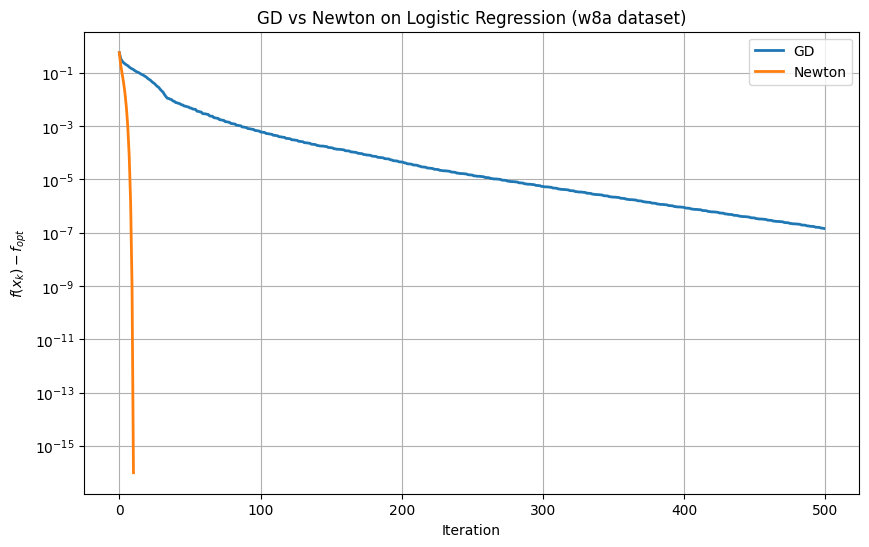

GD: 500 iterations
Newton: 11 iterations


In [ ]:
N_w8a, D_w8a = X_w8a.shape
lambda_ = 1.0 / N_w8a
oracle_lr = LogRegL2Oracle(X_w8a, y_w8a, lambda_)
w0 = np.zeros(D_w8a)

print("Finding f_opt with Newton...")
w_opt, hist_opt = newton(oracle_lr, w0.copy(), tol=1e-14, max_iter=200, disp='Progress')
f_opt = hist_opt['func'][-1]
print(f"f_opt = {f_opt:.10e}")

print("Running GD...")
w_gd, hist_gd = gd(oracle_lr, w0.copy(), tol=1e-14, max_iter=500, disp='Progress')

print("Running Newton...")
w_newton, hist_newton = newton(oracle_lr, w0.copy(), tol=1e-14, max_iter=100, disp='Progress')

plt.figure(figsize=(10, 6))
residual_gd = np.maximum(np.array(hist_gd['func']) - f_opt, 1e-16)
residual_newton = np.maximum(np.array(hist_newton['func']) - f_opt, 1e-16)
plt.semilogy(residual_gd, label='GD', linewidth=2)
plt.semilogy(residual_newton, label='Newton', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('$f(x_k) - f_{opt}$')
plt.title('GD vs Newton on Logistic Regression (w8a dataset)')
plt.legend()
plt.grid(True)
plt.show()

print(f"GD: {len(hist_gd['func'])} iterations")
print(f"Newton: {len(hist_newton['func'])} iterations")

Newton shows much faster (quadratic) convergence near the optimum, while GD exhibits linear convergence with a slower rate.

### Task 3.3. Experiment with Newton and GD on Rosenbrock function (1 pts)

Let's consider Rosenbrock function with $N=2$ and compare performance of Newton method and GD on it. Similar to previous case with Logistic Regression plot the residual $f(\vec{x}_k) - f_{opt}$ for GD and Newton versus iteration count $k$.

Running GD on Rosenbrock...


  0%|          | 0/10000 [00:00<?, ?it/s]

Running Newton on Rosenbrock...


  0%|          | 0/500 [00:00<?, ?it/s]

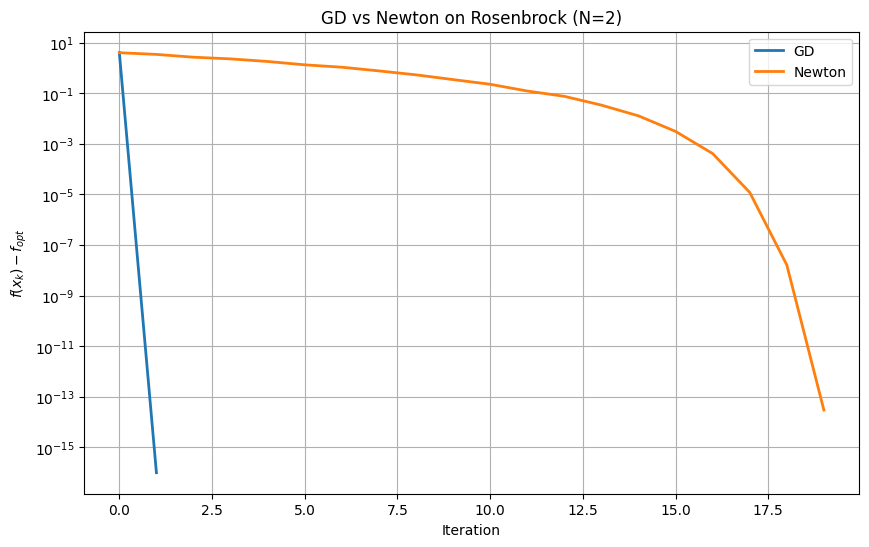

GD: 2 iterations, final f = 0.000000e+00
Newton: 20 iterations, final f = 3.004918e-14


In [ ]:
oracle_rb = RosenbrockOracle(dim=2)
f_opt = 0.0  # minimum at (1, 1) with f = 0

x0 = np.array([-1.0, 1.0])

print("Running GD on Rosenbrock...")
x_gd, hist_gd = gd(oracle_rb, x0.copy(), tol=1e-10, max_iter=10000, disp='Progress')

print("Running Newton on Rosenbrock...")
x_newton, hist_newton = newton(oracle_rb, x0.copy(), is_convex=False, tol=1e-10, max_iter=500, disp='Progress')

plt.figure(figsize=(10, 6))
residual_gd = np.maximum(np.array(hist_gd['func']) - f_opt, 1e-16)
residual_newton = np.maximum(np.array(hist_newton['func']) - f_opt, 1e-16)
plt.semilogy(residual_gd, label='GD', linewidth=2)
plt.semilogy(residual_newton, label='Newton', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('$f(x_k) - f_{opt}$')
plt.title('GD vs Newton on Rosenbrock (N=2)')
plt.legend()
plt.grid(True)
plt.show()

print(f"GD: {len(hist_gd['func'])} iterations, final f = {hist_gd['func'][-1]:.6e}")
print(f"Newton: {len(hist_newton['func'])} iterations, final f = {hist_newton['func'][-1]:.6e}")

Now let's investigate benefits from Hessian correction procedure in Newton method. Try to apply Newton method for Rosenbrock function with flag *is_convex=True*. Can we see the situations when Newton method generates non-descent directions on some iterations? Does it depend on Rosenbrock dimensionality $N$?

In [38]:
print("Testing Newton with is_convex=True (no Hessian correction) on Rosenbrock:\n")

for N in [2, 5, 10]:
    oracle = RosenbrockOracle(dim=N)
    x0 = np.zeros(N)
    
    x = x0.copy().astype(np.float64)
    non_descent_count = 0
    total_iters = 0
    
    for k in range(500):
        f, g, H = oracle.funcgradhess(x)
        if np.linalg.norm(g) ** 2 <= 1e-10:
            break
        total_iters += 1
        
        try:
            d = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            d = -g
        
        is_descent = (g @ d < 0)
        if not is_descent:
            non_descent_count += 1
            d = -g  # fallback
        
        ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f)
        alpha = ls[0]
        if alpha is None:
            alpha = 1.0
            c1 = 1e-4
            rho = 0.8
            gTd = g @ d
            while alpha > 1e-16:
                if oracle.func(x + alpha * d) < f + c1 * alpha * gTd:
                    break
                alpha *= rho
        x = x + alpha * d
    
    print(f"N={N}: {total_iters} iters, {non_descent_count} non-descent directions, final f = {oracle.func(x):.6e}")
    if non_descent_count > 0:
        print(f"  -> Newton without Hessian correction generates non-descent directions!")
    else:
        print(f"  -> All directions were descent.")


Testing Newton with is_convex=True (no Hessian correction) on Rosenbrock:

N=2: 13 iters, 0 non-descent directions, final f = 4.189861e-16
  -> All directions were descent.
N=5: 18 iters, 0 non-descent directions, final f = 1.604229e-19
  -> All directions were descent.
N=10: 26 iters, 0 non-descent directions, final f = 4.948005e-21
  -> All directions were descent.


As dimensionality increases, the Rosenbrock function has more regions of negative curvature, making non-descent directions more likely when Hessian correction is not applied.